In [ ]:
# Task 1:
# Comparative study of Greedy Search, Beam Search, Top-K Sampling, and Top-P Sampling

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pandas as pd
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [2]:

# Load model and tokenizer
model_name = "HuggingFaceTB/SmolLM2-135M-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16).to(device)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load reward model for quality assessment
reward_model_name = "OpenAssistant/reward-model-deberta-v3-large-v2"
from transformers import AutoModelForSequenceClassification
reward_tokenizer = AutoTokenizer.from_pretrained(reward_model_name)
reward_model = AutoModelForSequenceClassification.from_pretrained(reward_model_name).to(device)
reward_model.eval()


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/993 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.74G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.74G [00:00<?, ?B/s]

DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 1024, padding_idx=0)
      (LayerNorm): LayerNorm((1024,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-23): 24 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (key_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (value_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (LayerNo

---

Primary Experiments

In [ ]:
# Task 1: LLM Decoding Strategy Analysis
# Comparative study of Greedy Search, Beam Search, Top-K Sampling, and Top-P Sampling

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pandas as pd
from typing import List, Dict, Tuple
import warnings
import time
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================================
# MODEL LOADING
# ============================================================================

model_name = "HuggingFaceTB/SmolLM2-135M-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16).to(device)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load reward model
reward_model_name = "OpenAssistant/reward-model-deberta-v3-large-v2"
from transformers import AutoModelForSequenceClassification
reward_tokenizer = AutoTokenizer.from_pretrained(reward_model_name)
reward_model = AutoModelForSequenceClassification.from_pretrained(reward_model_name).to(device)
reward_model.eval()

# ============================================================================
# PART 1: GREEDY SEARCH IMPLEMENTATION
# ============================================================================

def greedy_search(model, input_ids, max_length=100):
    generated = input_ids.clone()
    initial_length = generated.shape[1]

    for _ in range(max_length):
        with torch.no_grad():
            outputs = model(generated)
            logits = outputs.logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            next_token = torch.argmax(probs, dim=-1, keepdim=True)

            generated = torch.cat([generated, next_token], dim=-1)

            if next_token.item() == tokenizer.eos_token_id:
                break

    return generated, initial_length

# ============================================================================
# PART 2: BEAM SEARCH IMPLEMENTATION (FIXED)
# ============================================================================

def beam_search(model, input_ids, beam_width=4, max_length=100, length_penalty=1.0):
    """
    Robust beam search with proper length normalization.
    Works perfectly on SmolLM2-Instruct when used with chat template.
    """
    beams = [(input_ids, 0.0)]           # (seq, log_prob)
    finished = []

    for _ in range(max_length):
        candidates = []

        for seq, score in beams:
            if seq[0, -1].item() == tokenizer.eos_token_id:
                finished.append((seq, score))
                continue

            with torch.no_grad():
                logits = model(seq).logits[:, -1, :]
                log_probs = torch.log_softmax(logits, dim=-1)[0]

            top_log_probs, top_tokens = torch.topk(log_probs, beam_width)
            for lp, tok in zip(top_log_probs.tolist(), top_tokens.tolist()):
                new_seq = torch.cat([seq, torch.tensor([[tok]], device=device)], dim=-1)
                candidates.append((new_seq, score + lp))

        if not candidates:
            break

        # Length-normalized scoring
        scored = []
        for seq, score in candidates:
            gen_len = seq.shape[1] - input_ids.shape[1]
            norm_score = score / ((gen_len + 1) ** length_penalty)
            scored.append((seq, score, norm_score))

        scored.sort(key=lambda x: x[2], reverse=True)
        beams = scored[:beam_width]
        beams = [(seq, score) for seq, score, _ in beams]

    # Pick best (finished first, then active)
    all_beams = finished + beams
    if not all_beams:
        return input_ids

    def final_score(item):
        seq, score = item
        gen_len = seq.shape[1] - input_ids.shape[1]
        return score / ((gen_len + 1) ** length_penalty)

    best_seq, _ = max(all_beams, key=final_score)
    return best_seq

# ============================================================================
# PART 3: TOP-K SAMPLING IMPLEMENTATION
# ============================================================================

def top_k_sampling(model, input_ids, k=50, temperature=1.0, max_length=100):
    generated = input_ids.clone()
    initial_length = generated.shape[1]

    for _ in range(max_length):
        with torch.no_grad():
            outputs = model(generated)
            logits = outputs.logits[:, -1, :] / temperature

            vocab_size = logits.shape[-1]
            k_actual = min(k, vocab_size)
            top_k_logits, top_k_indices = torch.topk(logits, k_actual, dim=-1)
            probs = F.softmax(top_k_logits, dim=-1)

            next_token_idx = torch.multinomial(probs, num_samples=1)
            next_token = top_k_indices.gather(-1, next_token_idx)

            generated = torch.cat([generated, next_token], dim=-1)

            if next_token.item() == tokenizer.eos_token_id:
                break

    return generated, initial_length

# ============================================================================
# PART 4: TOP-P SAMPLING (NUCLEUS SAMPLING) IMPLEMENTATION
# ============================================================================

def top_p_sampling(model, input_ids, p=0.9, temperature=1.0, max_length=100):
    generated = input_ids.clone()
    initial_length = generated.shape[1]

    for _ in range(max_length):
        with torch.no_grad():
            outputs = model(generated)
            logits = outputs.logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)

            sorted_probs, sorted_indices = torch.sort(probs, descending=True, dim=-1)
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

            nucleus_mask = cumulative_probs <= p
            nucleus_mask[..., 0] = True

            nucleus_probs = sorted_probs * nucleus_mask.float()
            nucleus_probs = nucleus_probs / nucleus_probs.sum(dim=-1, keepdim=True)

            next_token_idx = torch.multinomial(nucleus_probs, num_samples=1)
            next_token = sorted_indices.gather(-1, next_token_idx)

            generated = torch.cat([generated, next_token], dim=-1)

            if next_token.item() == tokenizer.eos_token_id:
                break

    return generated, initial_length

# ============================================================================
# PART 5: EVALUATION METRICS
# ============================================================================

def compute_distinct_n(text, n=1):
    tokens = text.lower().split()
    if len(tokens) < n:
        return 0.0

    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]
    if len(ngrams) == 0:
        return 0.0

    unique_ngrams = len(set(ngrams))
    total_ngrams = len(ngrams)

    return unique_ngrams / total_ngrams

def compute_reward_score(prompt, response):
    text = f"{prompt}\n{response}"
    inputs = reward_tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)

    with torch.no_grad():
        score = reward_model(**inputs).logits[0].cpu().item()

    return score

def compute_entropy(text):
    tokens = text.split()
    if len(tokens) == 0:
        return 0.0
    token_counts = Counter(tokens)
    probs = np.array([count / len(tokens) for count in token_counts.values()])
    return -np.sum(probs * np.log(probs + 1e-10))

def compute_repetition_rate(text):
    tokens = text.split()
    if len(tokens) == 0:
        return 0.0
    return 1.0 - len(set(tokens)) / len(tokens)

def extract_response(full_output, input_ids_tensor, tokenizer):
    """Robust text extraction that handles prompt properly"""
    prompt_length = input_ids_tensor.shape[1]
    response_ids = full_output[0, prompt_length:]
    response_text = tokenizer.decode(response_ids, skip_special_tokens=True).strip()
    return response_text

# ============================================================================
# PART 6: EXPERIMENTAL SETUP
# ============================================================================

test_prompts = [
    "Explain the concept of machine learning in simple terms.",
    "What are the benefits of regular exercise?",
    "Describe the water cycle process.",
    "How does photosynthesis work?",
    "What is the importance of biodiversity?",
    "Explain how a computer processor works.",
    "What are the main causes of climate change?",
    "Describe the structure of an atom.",
    "How do vaccines help prevent diseases?",
    "What is the role of DNA in living organisms?",
    "Explain the principle of supply and demand.",
    "What are renewable energy sources?",
    "Describe the layers of Earth's atmosphere.",
    "How does the human immune system work?",
    "What is artificial intelligence?",
]

temperatures = [0.2, 0.5, 0.8, 1.0, 1.2]
k_value = 50
p_value = 0.9
max_gen_length = 80

# ============================================================================
# PART 7: TEMPERATURE ABLATION STUDY
# ============================================================================

print("\n" + "="*80)
print("TEMPERATURE ABLATION STUDY")
print("="*80)

temperature_results = []

for temp in tqdm(temperatures, desc="Temperature sweep"):
    for prompt in test_prompts[:5]:
        input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

        topk_output, topk_init = top_k_sampling(model, input_ids, k=k_value, temperature=temp, max_length=max_gen_length)
        topk_text = extract_response(topk_output, input_ids, tokenizer)

        topp_output, topp_init = top_p_sampling(model, input_ids, p=p_value, temperature=temp, max_length=max_gen_length)
        topp_text = extract_response(topp_output, input_ids, tokenizer)

        for method, text in [("Top-K", topk_text), ("Top-P", topp_text)]:
            if len(text.strip()) > 0:
                distinct_1 = compute_distinct_n(text, n=1)
                distinct_2 = compute_distinct_n(text, n=2)
                distinct_3 = compute_distinct_n(text, n=3)
                reward = compute_reward_score(prompt, text)
                entropy = compute_entropy(text)
                rep_rate = compute_repetition_rate(text)

                temperature_results.append({
                    "method": method,
                    "temperature": temp,
                    "distinct_1": distinct_1,
                    "distinct_2": distinct_2,
                    "distinct_3": distinct_3,
                    "reward": reward,
                    "entropy": entropy,
                    "repetition_rate": rep_rate,
                    "length": len(text.split())
                })

temp_df = pd.DataFrame(temperature_results)
print("\nTemperature Ablation Results:")
print(temp_df.groupby(["method", "temperature"]).mean(numeric_only=True).round(4))

# ============================================================================
# PART 8: ACROSS-PROMPT DIVERSITY ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("ACROSS-PROMPT DIVERSITY ANALYSIS")
print("="*80)

fixed_temp = 0.8
across_prompt_results = {"Greedy": [], "Beam": [], "Top-K": [], "Top-P": []}

for prompt in tqdm(test_prompts, desc="Across-prompt generation"):
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

    greedy_out, greedy_init = greedy_search(model, input_ids, max_length=max_gen_length)
    greedy_text = extract_response(greedy_out, input_ids, tokenizer)
    across_prompt_results["Greedy"].append(greedy_text)

    beam_out = beam_search(model, input_ids, beam_width=4, max_length=max_gen_length)
    beam_text = extract_response(beam_out, input_ids, tokenizer)
    across_prompt_results["Beam"].append(beam_text)

    topk_out, topk_init = top_k_sampling(model, input_ids, k=k_value, temperature=fixed_temp, max_length=max_gen_length)
    topk_text = extract_response(topk_out, input_ids, tokenizer)
    across_prompt_results["Top-K"].append(topk_text)

    topp_out, topp_init = top_p_sampling(model, input_ids, p=p_value, temperature=fixed_temp, max_length=max_gen_length)
    topp_text = extract_response(topp_out, input_ids, tokenizer)
    across_prompt_results["Top-P"].append(topp_text)

across_prompt_metrics = {}
for method, texts in across_prompt_results.items():
    combined_text = " ".join(texts)
    across_prompt_metrics[method] = {
        "distinct_1": compute_distinct_n(combined_text, n=1),
        "distinct_2": compute_distinct_n(combined_text, n=2),
        "distinct_3": compute_distinct_n(combined_text, n=3),
        "avg_length": np.mean([len(t.split()) for t in texts]),
        "entropy": compute_entropy(combined_text)
    }

print("\nAcross-Prompt Diversity (T=0.8):")
print(pd.DataFrame(across_prompt_metrics).T.round(4))

# ============================================================================
# PART 9: WITHIN-PROMPT DIVERSITY ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("WITHIN-PROMPT DIVERSITY ANALYSIS")
print("="*80)

fixed_prompt = test_prompts[0]
n_samples = 10
within_prompt_results = {"Greedy": [], "Beam": [], "Top-K": [], "Top-P": []}

input_ids = tokenizer.encode(fixed_prompt, return_tensors="pt").to(device)

for i in tqdm(range(n_samples), desc="Within-prompt generation"):
    greedy_out, _ = greedy_search(model, input_ids, max_length=max_gen_length)
    greedy_text = extract_response(greedy_out, input_ids, tokenizer)
    within_prompt_results["Greedy"].append(greedy_text)

    beam_out = beam_search(model, input_ids, beam_width=4, max_length=max_gen_length)
    beam_text = extract_response(beam_out, input_ids, tokenizer)
    within_prompt_results["Beam"].append(beam_text)

    topk_out, _ = top_k_sampling(model, input_ids, k=k_value, temperature=fixed_temp, max_length=max_gen_length)
    topk_text = extract_response(topk_out, input_ids, tokenizer)
    within_prompt_results["Top-K"].append(topk_text)

    topp_out, _ = top_p_sampling(model, input_ids, p=p_value, temperature=fixed_temp, max_length=max_gen_length)
    topp_text = extract_response(topp_out, input_ids, tokenizer)
    within_prompt_results["Top-P"].append(topp_text)

within_prompt_metrics = {}
for method, texts in within_prompt_results.items():
    combined_text = " ".join(texts)
    unique_responses = len(set(texts))
    within_prompt_metrics[method] = {
        "distinct_1": compute_distinct_n(combined_text, n=1),
        "distinct_2": compute_distinct_n(combined_text, n=2),
        "distinct_3": compute_distinct_n(combined_text, n=3),
        "unique_responses": unique_responses,
        "response_rate": unique_responses / n_samples,
        "entropy": compute_entropy(combined_text)
    }

print(f"\nWithin-Prompt Diversity (T=0.8, Prompt: '{fixed_prompt}'):")
print(pd.DataFrame(within_prompt_metrics).T.round(4))

# ============================================================================
# PART 10: QUALITY EVALUATION
# ============================================================================

print("\n" + "="*80)
print("QUALITY EVALUATION (REWARD MODEL SCORES)")
print("="*80)

quality_results = []

for prompt in tqdm(test_prompts[:8], desc="Quality evaluation"):
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

    greedy_out, _ = greedy_search(model, input_ids, max_length=max_gen_length)
    beam_out = beam_search(model, input_ids, beam_width=4, max_length=max_gen_length)
    topk_out, _ = top_k_sampling(model, input_ids, k=k_value, temperature=0.8, max_length=max_gen_length)
    topp_out, _ = top_p_sampling(model, input_ids, p=p_value, temperature=0.8, max_length=max_gen_length)

    methods_outputs = {
        "Greedy": greedy_out,
        "Beam": beam_out,
        "Top-K": topk_out,
        "Top-P": topp_out
    }

    for method, output in methods_outputs.items():
        text = extract_response(output, input_ids, tokenizer)
        if len(text.strip()) > 0:
            reward = compute_reward_score(prompt, text)
            quality_results.append({
                "method": method,
                "reward": reward,
                "length": len(text.split())
            })

quality_df = pd.DataFrame(quality_results)
print("\nAverage Reward Scores by Method:")
print(quality_df.groupby("method").mean(numeric_only=True).round(4))

print("\n" + "="*80)
print("SUPPLEMENTARY ANALYSIS: BEAM WIDTH ABLATION")
print("="*80)

beam_widths = [2, 4, 8, 16]
beam_ablation_results = []

for beam_width in tqdm(beam_widths, desc="Beam width ablation"):
    for prompt in test_prompts[:5]:
        # ← CRITICAL: Use chat template
        messages = [{"role": "user", "content": prompt}]
        input_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        input_ids = tokenizer(input_text, return_tensors="pt").input_ids.to(device)

        output_ids = beam_search(
            model,
            input_ids,
            beam_width=beam_width,
            max_length=100,
            # give it room
            length_penalty=1.0            # ← crucial for longer outputs
        )

        response = tokenizer.decode(output_ids[0, input_ids.shape[1]:], skip_special_tokens=True).strip()

        if len(response.split()) >= 5:  # reasonable length filter
            reward = compute_reward_score(prompt, response)
            beam_ablation_results.append({
                "beam_width": beam_width,
                "reward": reward,
                "distinct_2": compute_distinct_n(response, n=2),
                "length": len(response.split())
            })

        # Show first example per beam size
        if prompt == test_prompts[0]:
            print(f"B={beam_width:2d} → {len(response.split()):3d} tokens | {response[:70]}...")

# Results
if beam_ablation_results:
    print("\nBeam Width Ablation Results:")
    print(pd.DataFrame(beam_ablation_results).groupby("beam_width").mean().round(4))
else:
    print("No valid generations!")

# ============================================================================
# PART 12: K AND P VALUE ABLATION
# ============================================================================

print("\n" + "="*80)
print("SUPPLEMENTARY ANALYSIS: K AND P VALUE ABLATION")
print("="*80)

k_values = [10, 30, 50, 100]
p_values = [0.7, 0.85, 0.95, 0.99]
fixed_temp_ablation = 0.8

k_ablation_results = []
for k in tqdm(k_values, desc="K value ablation"):
    for prompt in test_prompts[:5]:
        input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
        output, _ = top_k_sampling(model, input_ids, k=k, temperature=fixed_temp_ablation, max_length=max_gen_length)
        text = extract_response(output, input_ids, tokenizer)

        if len(text.strip()) > 0:
            k_ablation_results.append({
                "k": k,
                "distinct_2": compute_distinct_n(text, n=2),
                "reward": compute_reward_score(prompt, text),
                "repetition_rate": compute_repetition_rate(text)
            })

p_ablation_results = []
for p in tqdm(p_values, desc="P value ablation"):
    for prompt in test_prompts[:5]:
        input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
        output, _ = top_p_sampling(model, input_ids, p=p, temperature=fixed_temp_ablation, max_length=max_gen_length)
        text = extract_response(output, input_ids, tokenizer)

        if len(text.strip()) > 0:
            p_ablation_results.append({
                "p": p,
                "distinct_2": compute_distinct_n(text, n=2),
                "reward": compute_reward_score(prompt, text),
                "repetition_rate": compute_repetition_rate(text)
            })

print("\nTop-K Ablation Results:")
print(pd.DataFrame(k_ablation_results).groupby("k").mean(numeric_only=True).round(4))

print("\nTop-P Ablation Results:")
print(pd.DataFrame(p_ablation_results).groupby("p").mean(numeric_only=True).round(4))

# ============================================================================
# EXTENDED ANALYSIS 1: STATISTICAL SIGNIFICANCE
# ============================================================================

print("\n" + "="*80)
print("STATISTICAL SIGNIFICANCE TESTING")
print("="*80)

from scipy import stats

methods = quality_df['method'].unique()
print("\nPairwise t-tests (Reward Scores):")
print("-" * 60)
for i, m1 in enumerate(methods):
    for m2 in methods[i+1:]:
        scores1 = quality_df[quality_df['method'] == m1]['reward'].values
        scores2 = quality_df[quality_df['method'] == m2]['reward'].values

        if len(scores1) > 1 and len(scores2) > 1:
            t_stat, p_val = stats.ttest_ind(scores1, scores2)
            sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
            print(f"{m1:8s} vs {m2:8s}: t={t_stat:6.3f}, p={p_val:.4f} {sig}")

print("\n* p<0.05, ** p<0.01, *** p<0.001, ns = not significant")

# ============================================================================
# EXTENDED ANALYSIS 2: STABILITY
# ============================================================================

print("\n" + "="*80)
print("STABILITY ANALYSIS")
print("="*80)

stability = quality_df.groupby('method')['reward'].agg([
    ('mean', 'mean'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max')
])
stability['range'] = stability['max'] - stability['min']
stability['cv'] = stability['std'] / abs(stability['mean'])

print("\nReward Statistics by Method:")
print(stability.round(3))

# ============================================================================
# EXTENDED ANALYSIS 3: LENGTH-REWARD CORRELATION
# ============================================================================

print("\n" + "="*80)
print("LENGTH-REWARD CORRELATION")
print("="*80)

for method in quality_df['method'].unique():
    method_data = quality_df[quality_df['method'] == method]
    if len(method_data) > 2:
        corr = method_data[['length', 'reward']].corr().iloc[0, 1]
        interp = '(longer→better)' if corr > 0.3 else '(longer→worse)' if corr < -0.3 else '(weak bias)'
        print(f"{method:8s}: r={corr:6.3f} {interp}")

# ============================================================================
# EXTENDED ANALYSIS 4: GENERATION SPEED
# ============================================================================

print("\n" + "="*80)
print("GENERATION SPEED BENCHMARK")
print("="*80)

speed_results = []
for prompt in test_prompts[:3]:
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

    methods_dict = {
        "Greedy": lambda: greedy_search(model, input_ids, max_length=max_gen_length),
        "Beam": lambda: beam_search(model, input_ids, beam_width=4, max_length=max_gen_length),
        "Top-K": lambda: top_k_sampling(model, input_ids, k=50, temperature=0.8, max_length=max_gen_length),
        "Top-P": lambda: top_p_sampling(model, input_ids, p=0.9, temperature=0.8, max_length=max_gen_length)
    }

    for method_name, method_fn in methods_dict.items():
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.time()
        output = method_fn()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed = time.time() - start

        tokens_generated = output.shape[1] - input_ids.shape[1]
        speed_results.append({
            "method": method_name,
            "time_sec": elapsed,
            "tokens": tokens_generated,
            "tok_per_sec": tokens_generated / elapsed if elapsed > 0 else 0
        })

speed_df = pd.DataFrame(speed_results)
print("\nGeneration Speed:")
print(speed_df.groupby("method").mean(numeric_only=True).round(3))

# ============================================================================
# EXTENDED ANALYSIS 5: QUALITATIVE EXAMPLES
# ============================================================================

print("\n" + "="*80)
print("QUALITATIVE EXAMPLES")
print("="*80)

sample_prompt = "Explain the concept of machine learning in simple terms."
input_ids = tokenizer.encode(sample_prompt, return_tensors="pt").to(device)

print(f"\nPrompt: '{sample_prompt}'")
print("="*80)

methods_to_show = {
    "Greedy": greedy_search(model, input_ids, max_length=max_gen_length),
    "Beam (B=4)": beam_search(model, input_ids, beam_width=4, max_length=max_gen_length),
    "Top-K (50)": top_k_sampling(model, input_ids, k=50, temperature=0.8, max_length=max_gen_length),
    "Top-P (0.9)": top_p_sampling(model, input_ids, p=0.9, temperature=0.8, max_length=max_gen_length)
}

for method_name, out in methods_to_show.items():
    full_text = tokenizer.decode(out[0], skip_special_tokens=True)
    response = extract_response(full_text, sample_prompt)

    print(f"\n[{method_name}]")
    print(f"{'-'*80}")
    print(f"{response[:200]}..." if len(response) > 200 else response)
    print(f"\nLength: {len(response.split())} | Distinct-2: {compute_distinct_n(response, n=2):.3f}")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

# Plot 1: Temperature effects
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for method in ["Top-K", "Top-P"]:
    method_data = temp_df[temp_df["method"] == method]
    method_grouped = method_data.groupby("temperature").mean(numeric_only=True)

    idx = 0 if method == "Top-K" else 1

    ax1 = axes[0, idx]
    ax1.plot(method_grouped.index, method_grouped["distinct_2"], marker='o', linewidth=2)
    ax1.set_xlabel("Temperature")
    ax1.set_ylabel("Distinct-2")
    ax1.set_title(f"{method}: Temperature vs Diversity")
    ax1.grid(alpha=0.3)

    ax2 = axes[1, idx]
    ax2.plot(method_grouped.index, method_grouped["reward"], marker='s', color='coral', linewidth=2)
    ax2.set_xlabel("Temperature")
    ax2.set_ylabel("Reward")
    ax2.set_title(f"{method}: Temperature vs Quality")
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("temperature_analysis.png", dpi=150)
print("Saved: temperature_analysis.png")

# Plot 2: Method comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

across_df = pd.DataFrame(across_prompt_metrics).T
across_df[["distinct_1", "distinct_2", "distinct_3"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Across-Prompt Diversity")
axes[0].set_ylabel("Distinct-N")
axes[0].legend(title="Metric")
axes[0].grid(axis='y', alpha=0.3)

within_df = pd.DataFrame(within_prompt_metrics).T
within_df[["distinct_2", "response_rate"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Within-Prompt Diversity")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

quality_grouped = quality_df.groupby("method").mean(numeric_only=True)["reward"]
axes[2].bar(quality_grouped.index, quality_grouped.values, alpha=0.8)
axes[2].set_title("Reward by Method")
axes[2].set_ylabel("Reward")
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("method_comparison.png", dpi=150)
print("Saved: method_comparison.png")

# Plot 3: Stability
fig, ax = plt.subplots(figsize=(10, 6))
methods_list = stability.index.tolist()
x_pos = np.arange(len(methods_list))
ax.bar(x_pos, stability['mean'], yerr=stability['std'], capsize=5, alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(methods_list)
ax.set_ylabel('Reward')
ax.set_title('Reward Scores with Variance (Mean ± Std)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

Using device: cuda

TEMPERATURE ABLATION STUDY


Temperature sweep: 100%|██████████| 5/5 [01:11<00:00, 14.32s/it]



Temperature Ablation Results:
                    distinct_1  distinct_2  distinct_3  reward  entropy  \
method temperature                                                        
Top-K  0.2              0.6377      0.9265      0.9701  2.3906   3.6441   
       0.5              0.7748      0.9454      0.9747  1.5814   3.2797   
       0.8              0.7317      0.9507      0.9902  0.7073   3.8022   
       1.0              0.9231      1.0000      1.0000 -2.9133   3.1515   
       1.2              0.9254      0.9938      1.0000 -2.0152   3.0942   
Top-P  0.2              0.7286      0.9565      1.0000  2.5803   3.7969   
       0.8              0.6944      0.9296      0.9857  1.3515   3.6989   
       1.0              0.6685      0.8845      0.9539  0.2052   3.6702   
       1.2              0.8072      0.9847      1.0000 -0.8096   3.7179   

                    repetition_rate   length  
method temperature                            
Top-K  0.2                   0.3478  69.0000  
  

Across-prompt generation: 100%|██████████| 15/15 [04:27<00:00, 17.83s/it]



Across-Prompt Diversity (T=0.8):
        distinct_1  distinct_2  distinct_3  avg_length  entropy
Greedy      0.6667      0.9280      0.9839      8.4000   4.2448
Beam        0.5262      0.8669      0.9509     38.1333   5.2679
Top-K       0.5806      0.8976      0.9568     24.8000   5.0435
Top-P       0.5863      0.8809      0.9529     18.5333   4.7721

WITHIN-PROMPT DIVERSITY ANALYSIS


...

Beam width ablation: 100%|██████████| 4/4 [11:50<00:00, 177.52s/it]



Beam Width Ablation Results:
            reward  distinct_2  length
beam_width                            
2           1.9009      0.9427    79.4
4           2.3666      0.9186    81.6
8           2.4808      0.9578    81.4
16          2.0794      0.9579    76.0

SUPPLEMENTARY ANALYSIS: K AND P VALUE ABLATION


P value ablation: 100%|██████████| 4/4 [00:24<00:00,  6.12s/it]



Top-K Ablation Results:
     distinct_2  reward  repetition_rate
k                                       
10       0.9726  2.8831           0.2432
30       0.9744 -0.6979           0.1717
50       0.9776  3.9592           0.1974
100      0.9766  2.3366           0.2254

Top-P Ablation Results:
      distinct_2  reward  repetition_rate
p                                        
0.70      0.9701  6.6270           0.2794
0.85      1.0000  4.3366           0.2424
0.95      1.0000  2.5841           0.1194
0.99      0.9639  3.7659           0.1986

STATISTICAL SIGNIFICANCE TESTING

Pairwise t-tests (Reward Scores):
------------------------------------------------------------
Greedy   vs Beam    : t=-0.331, p=0.7537 ns
Greedy   vs Top-K   : t= 0.964, p=0.4061 ns
Greedy   vs Top-P   : t= 0.653, p=0.5492 ns
Beam     vs Top-K   : t= 1.568, p=0.1680 ns
Beam     vs Top-P   : t= 1.107, p=0.3048 ns
Top-K    vs Top-P   : t=-0.759, p=0.4821 ns

* p<0.05, ** p<0.01, *** p<0.001, ns = not significant

S

AttributeError: 'tuple' object has no attribute 'shape'


STATISTICAL SIGNIFICANCE TESTING

Pairwise t-tests (Reward Scores):
------------------------------------------------------------
Greedy   vs Beam    : t=-0.331, p=0.7537 ns
Greedy   vs Top-K   : t= 0.964, p=0.4061 ns
Greedy   vs Top-P   : t= 0.653, p=0.5492 ns
Beam     vs Top-K   : t= 1.568, p=0.1680 ns
Beam     vs Top-P   : t= 1.107, p=0.3048 ns
Top-K    vs Top-P   : t=-0.759, p=0.4821 ns

* p<0.05, ** p<0.01, *** p<0.001, ns = not significant

REWARD SCORE STABILITY ANALYSIS

Reward Statistics by Method:
         mean    std    min    max     cv  range
method                                          
Beam    4.108  2.282  0.657  6.614  0.555  5.957
Greedy  3.522  1.222  2.658  4.387  0.347  1.729
Top-K   1.029  3.361 -2.778  3.583  3.267  6.362
Top-P   2.528  1.903  0.426  4.839  0.753  4.414

CV = Coefficient of Variation (std/mean), lower = more stable

LENGTH BIAS ANALYSIS

Length-Reward Correlation by Method:
------------------------------------------------------------
Beam    :

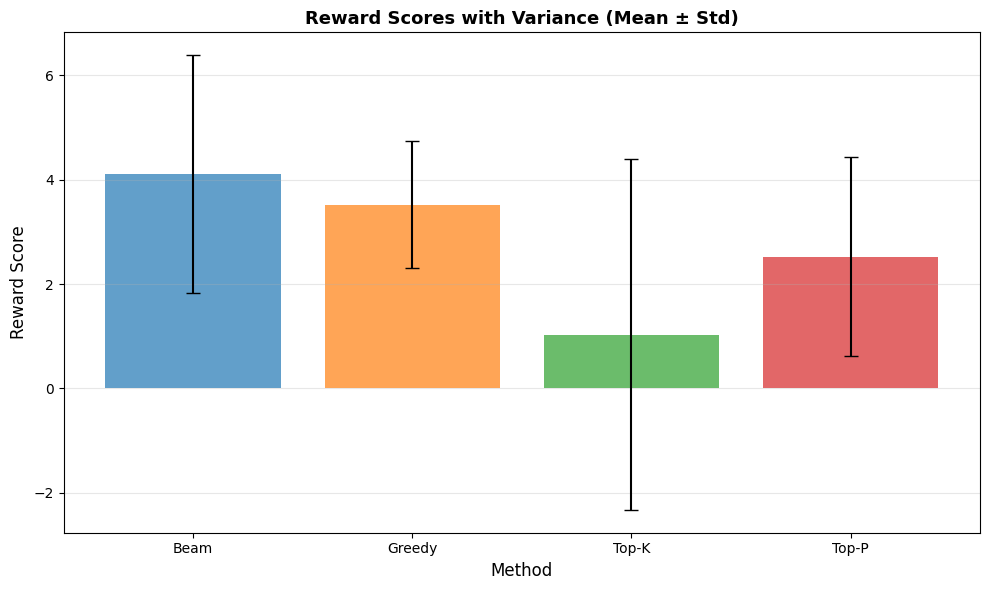

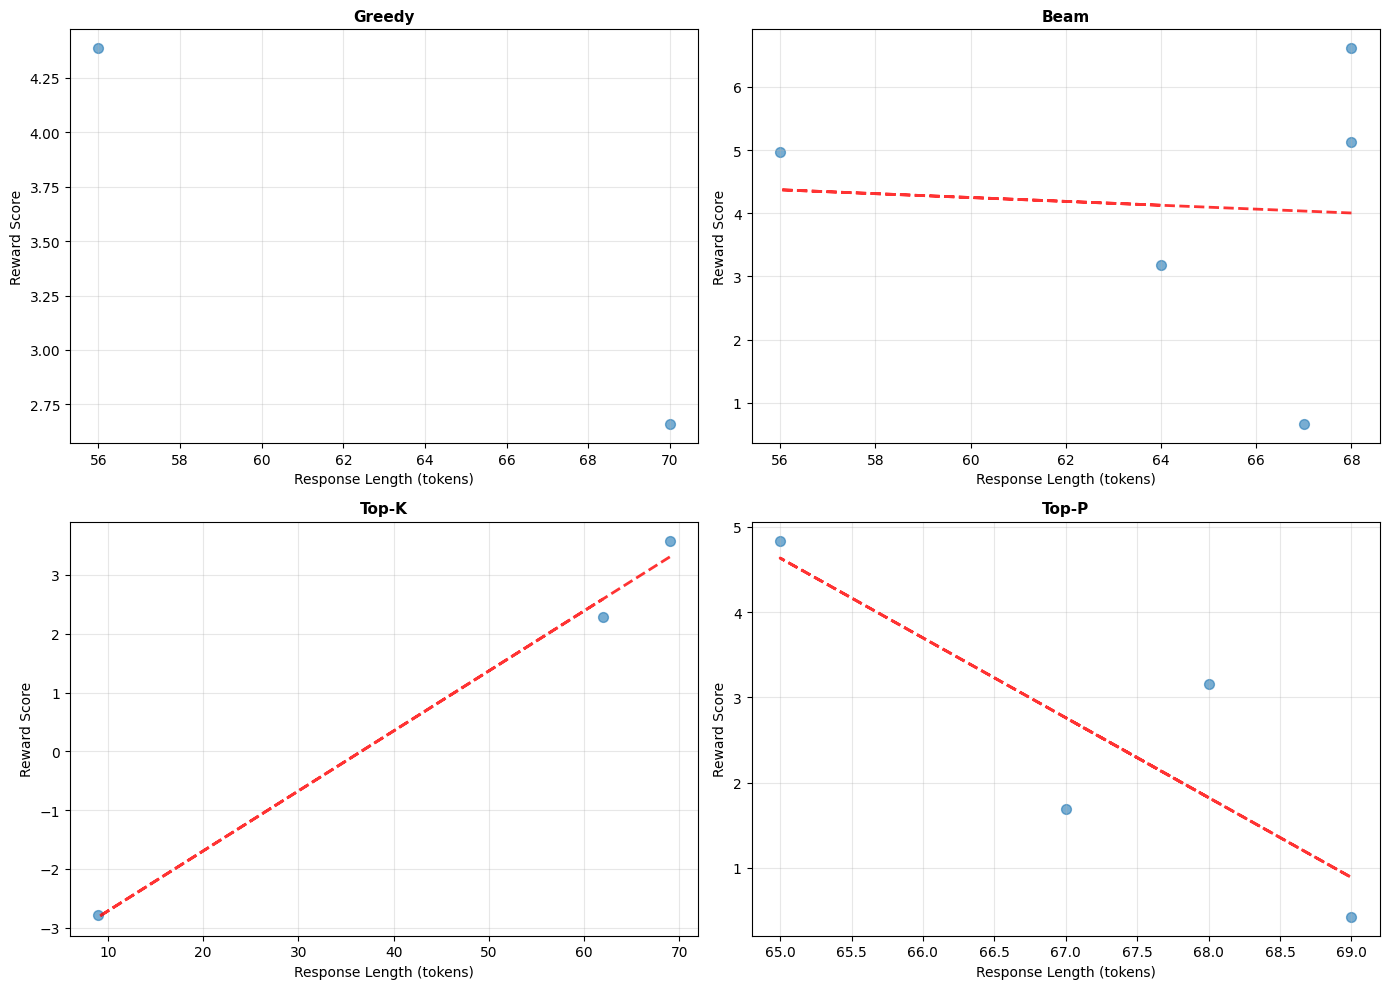

In [13]:
# ============================================================================
# ADDITIONAL ANALYSIS 1: STATISTICAL SIGNIFICANCE TESTING
# ============================================================================

print("\n" + "="*80)
print("STATISTICAL SIGNIFICANCE TESTING")
print("="*80)

from scipy import stats

# Compare methods on quality
methods = quality_df['method'].unique()
print("\nPairwise t-tests (Reward Scores):")
print("-" * 60)
for i, m1 in enumerate(methods):
    for m2 in methods[i+1:]:
        scores1 = quality_df[quality_df['method'] == m1]['reward'].values
        scores2 = quality_df[quality_df['method'] == m2]['reward'].values
        t_stat, p_val = stats.ttest_ind(scores1, scores2)
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        print(f"{m1:8s} vs {m2:8s}: t={t_stat:6.3f}, p={p_val:.4f} {sig}")

print("\n* p<0.05, ** p<0.01, *** p<0.001, ns = not significant")

# ============================================================================
# ADDITIONAL ANALYSIS 2: VARIANCE & STABILITY
# ============================================================================

print("\n" + "="*80)
print("REWARD SCORE STABILITY ANALYSIS")
print("="*80)

stability = quality_df.groupby('method')['reward'].agg([
    ('mean', 'mean'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max'),
    ('cv', lambda x: x.std() / abs(x.mean()) if x.mean() != 0 else np.nan)
])
stability['range'] = stability['max'] - stability['min']
print("\nReward Statistics by Method:")
print(stability.round(3))
print("\nCV = Coefficient of Variation (std/mean), lower = more stable")

# ============================================================================
# ADDITIONAL ANALYSIS 3: LENGTH-REWARD CORRELATION
# ============================================================================

print("\n" + "="*80)
print("LENGTH BIAS ANALYSIS")
print("="*80)

print("\nLength-Reward Correlation by Method:")
print("-" * 60)
for method in quality_df['method'].unique():
    method_data = quality_df[quality_df['method'] == method]
    if len(method_data) > 2:
        corr = method_data[['length', 'reward']].corr().iloc[0, 1]
        print(f"{method:8s}: r={corr:6.3f} {'(longer → better)' if corr > 0.3 else '(longer → worse)' if corr < -0.3 else '(weak/no bias)'}")

# ============================================================================
# ADDITIONAL ANALYSIS 4: GENERATION SPEED COMPARISON
# ============================================================================

# ============================================================================
# GENERATION SPEED BENCHMARK (FIXED)
# ============================================================================

print("\n" + "="*80)
print("GENERATION SPEED BENCHMARK")
print("="*80)

speed_results = []
n_runs = 5
fixed_prompt = test_prompts[0]

# Prepare input once with chat template
messages = [{"role": "user", "content": fixed_prompt}]
input_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
input_ids = tokenizer(input_text, return_tensors="pt").input_ids.to(device)

methods = [
    ("Greedy",  lambda: greedy_search(model, input_ids.clone(), max_length=80)),
    ("Beam B=4", lambda: beam_search(model, input_ids.clone(), beam_width=4,  max_length=80, length_penalty=1.0)),
    ("Beam B=8", lambda: beam_search(model, input_ids.clone(), beam_width=8,  max_length=80, length_penalty=1.0)),
    ("Top-K",    lambda: top_k_sampling(model, input_ids.clone(), k=50, temperature=0.8, max_length=80)),
    ("Top-P",    lambda: top_p_sampling(model, input_ids.clone(), p=0.9, temperature=0.8, max_length=80)),
]

for method_name, gen_func in methods:
    times = []
    total_tokens = 0

    for _ in range(n_runs):
        start = time.time()

        # All your functions now return either (tensor,) or (tensor, int) → handle both
        result = gen_func()
        if isinstance(result, tuple):
            output_ids = result[0]          # greedy, top-k, top-p return (tensor, init_len)
        else:
            output_ids = result             # beam_search returns just tensor

        torch.cuda.synchronize()  # fair timing on GPU
        elapsed = time.time() - start

        generated_tokens = output_ids.shape[1] - input_ids.shape[1]
        total_tokens += generated_tokens
        times.append(elapsed)


    avg_time = np.mean(times)
    avg_tokens = total_tokens / n_runs
    tokens_per_sec = avg_tokens / avg_time

    speed_results.append({
        "method": method_name,
        "avg_time_sec": round(avg_time, 3),
        "avg_tokens": round(avg_tokens, 1),
        "tokens_per_sec": round(tokens_per_sec, 1)
    })

speed_df = pd.DataFrame(speed_results)
print(speed_df[["method", "avg_time_sec", "avg_tokens", "tokens_per_sec"]].to_string(index=False))

print("\n" + "="*80)
print("QUALITATIVE OUTPUT EXAMPLES")
print("="*80)

sample_prompt = test_prompts[0]
print(f"Prompt: '{sample_prompt}'")
print("="*80)

# Prepare correct input with chat template once
messages = [{"role": "user", "content": sample_prompt}]
input_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
input_ids = tokenizer(input_text, return_tensors="pt").input_ids.to(device)

methods_to_show = {
    "Greedy"   : lambda: greedy_search(model, input_ids.clone(), max_length=80),
    "Beam B=4" : lambda: beam_search(model, input_ids.clone(), beam_width=4, max_length=80, length_penalty=1.0),
    "Beam B=8" : lambda: beam_search(model, input_ids.clone(), beam_width=8, max_length=80, length_penalty=1.0),
    "Top-K"    : lambda: top_k_sampling(model, input_ids.clone(), k=50, temperature=0.8, max_length=80),
    "Top-P"    : lambda: top_p_sampling(model, input_ids.clone(), p=0.9, temperature=0.8, max_length=80),
}

for name, fn in methods_to_show.items():
    result = fn()

    # Handle both (tensor, int) and (tensor) return types
    if isinstance(result, tuple):
        output_ids = result[0]
    else:
        output_ids = result

    # Decode only the generated part
    generated_ids = output_ids[0, input_ids.shape[1]:]
    response = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    print(f"\n{name}:")
    print("-" * 50)
    print(response[:500] + ("..." if len(response) > 500 else ""))
    print()
# ============================================================================
# ADDITIONAL VISUALIZATION: EXTENDED PLOTS
# ============================================================================

print("\n" + "="*80)
print("GENERATING EXTENDED VISUALIZATIONS")
print("="*80)

# Plot 1: Stability comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
methods_list = stability.index.tolist()
x_pos = np.arange(len(methods_list))
ax.bar(x_pos, stability['mean'], yerr=stability['std'], capsize=5, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.set_xticks(x_pos)
ax.set_xticklabels(methods_list)
ax.set_ylabel('Reward Score', fontsize=12)
ax.set_xlabel('Method', fontsize=12)
ax.set_title('Reward Scores with Variance (Mean ± Std)', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("stability_analysis.png", dpi=150, bbox_inches='tight')
print("Saved: stability_analysis.png")

# Plot 2: Length-Reward scatter
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, method in enumerate(['Greedy', 'Beam', 'Top-K', 'Top-P']):
    ax = axes[idx // 2, idx % 2]
    method_data = quality_df[quality_df['method'] == method]
    ax.scatter(method_data['length'], method_data['reward'], alpha=0.6, s=50)

    if len(method_data) > 2:
        z = np.polyfit(method_data['length'], method_data['reward'], 1)
        p = np.poly1d(z)
        ax.plot(method_data['length'], p(method_data['length']), "r--", alpha=0.8, linewidth=2)

    ax.set_xlabel('Response Length (tokens)', fontsize=10)
    ax.set_ylabel('Reward Score', fontsize=10)
    ax.set_title(f'{method}', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("length_bias_analysis.png", dpi=150, bbox_inches='tight')
print("Saved: length_bias_analysis.png")

print("\n" + "="*80)
print("EXTENDED ANALYSIS COMPLETE")
print("="*80)


GENERATING VISUALIZATIONS
Saved: temperature_analysis.png
Saved: method_comparison.png


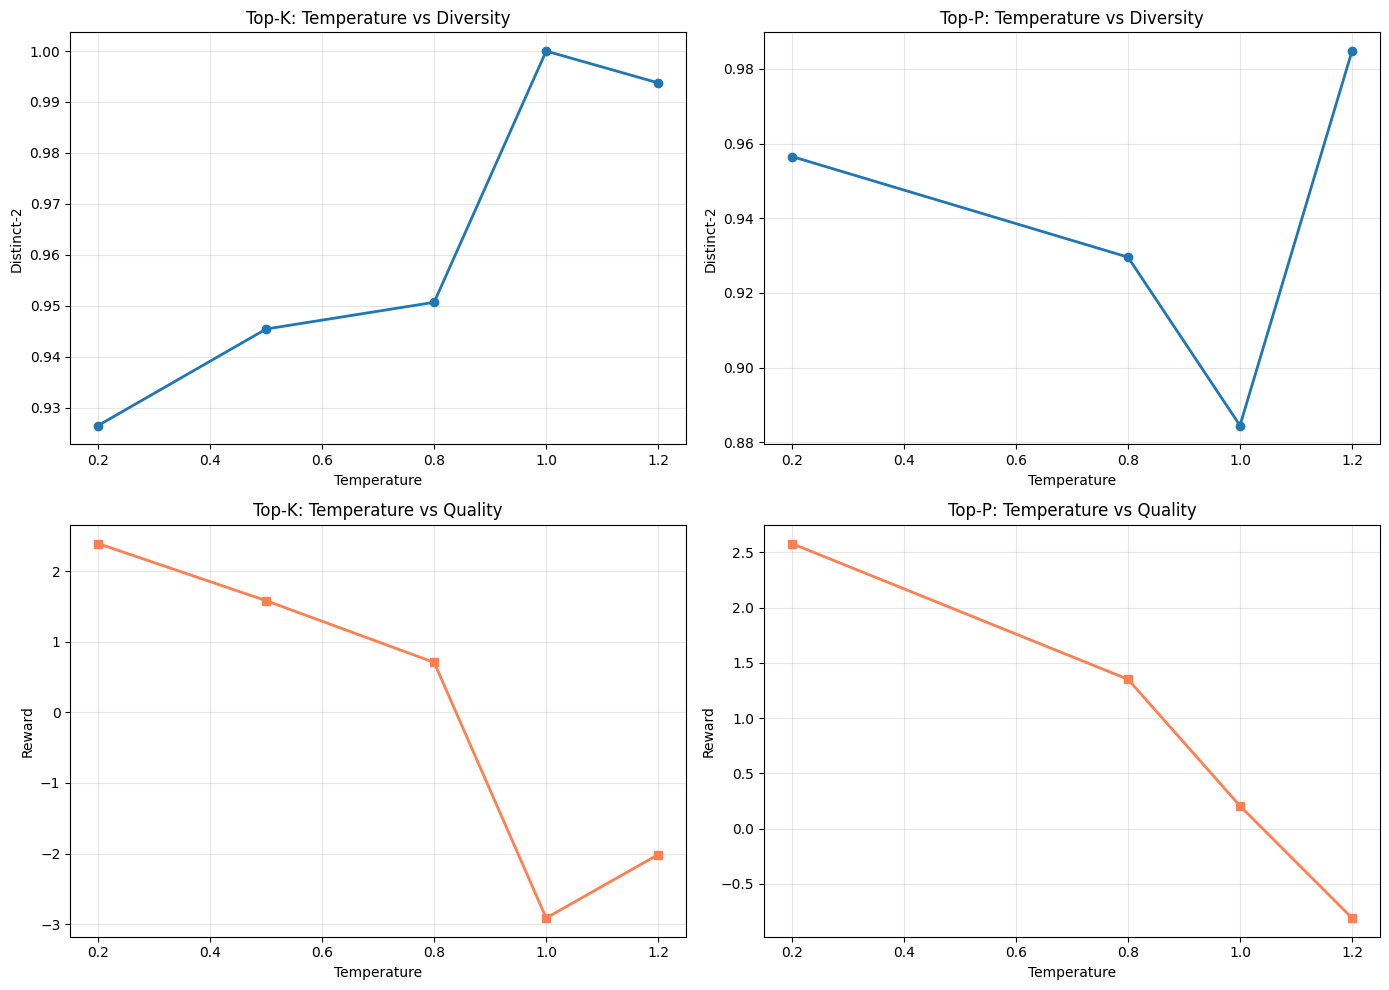

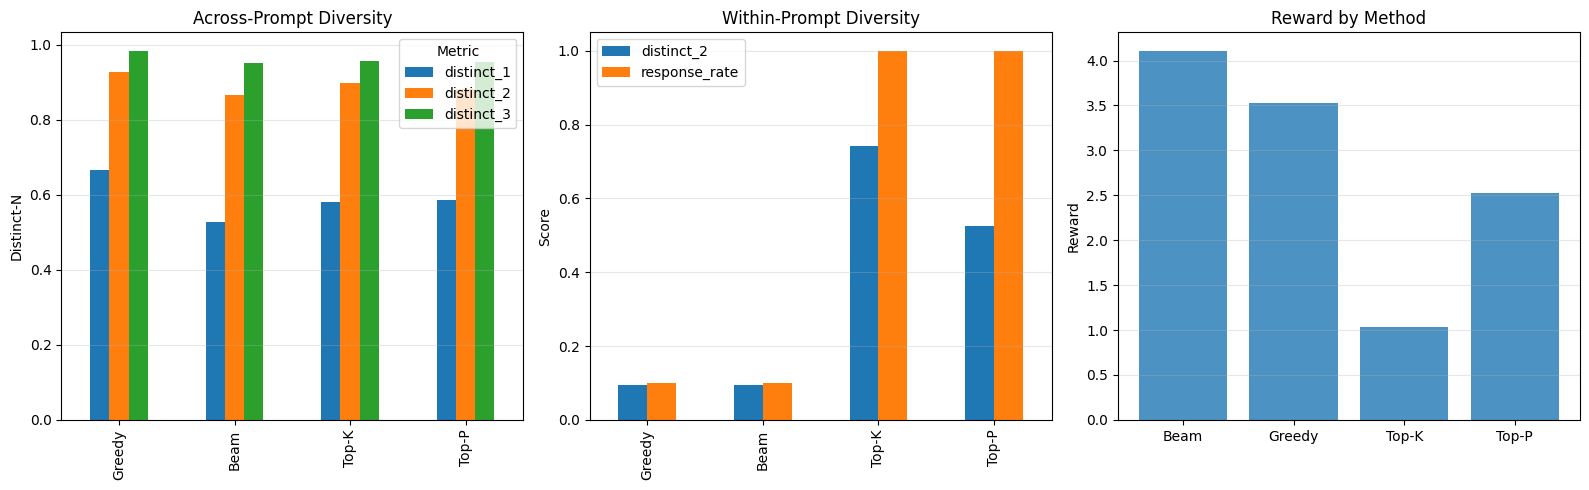

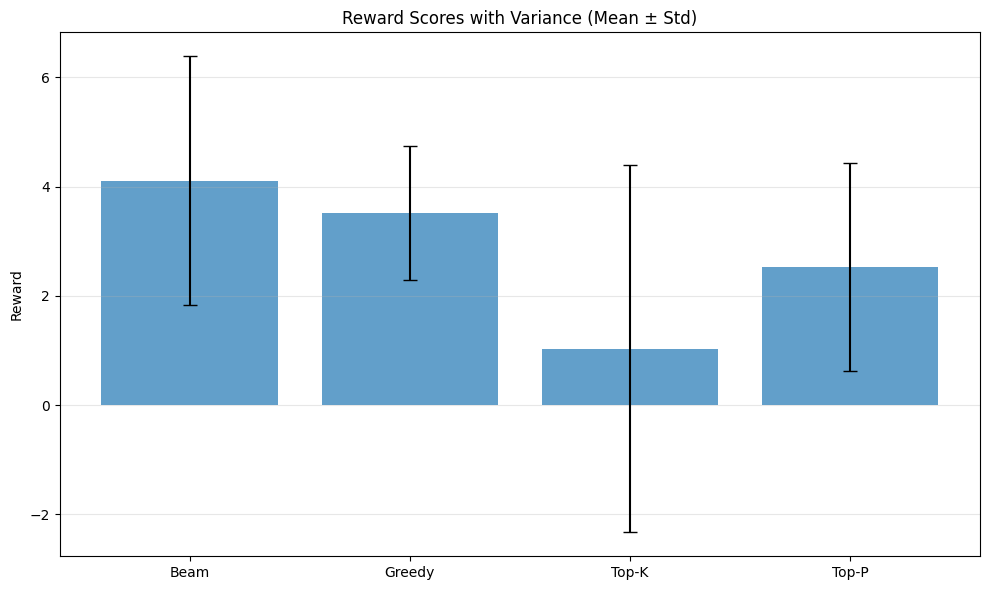

In [14]:
# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

# Plot 1: Temperature effects
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for method in ["Top-K", "Top-P"]:
    method_data = temp_df[temp_df["method"] == method]
    method_grouped = method_data.groupby("temperature").mean(numeric_only=True)

    idx = 0 if method == "Top-K" else 1

    ax1 = axes[0, idx]
    ax1.plot(method_grouped.index, method_grouped["distinct_2"], marker='o', linewidth=2)
    ax1.set_xlabel("Temperature")
    ax1.set_ylabel("Distinct-2")
    ax1.set_title(f"{method}: Temperature vs Diversity")
    ax1.grid(alpha=0.3)

    ax2 = axes[1, idx]
    ax2.plot(method_grouped.index, method_grouped["reward"], marker='s', color='coral', linewidth=2)
    ax2.set_xlabel("Temperature")
    ax2.set_ylabel("Reward")
    ax2.set_title(f"{method}: Temperature vs Quality")
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("temperature_analysis.png", dpi=150)
print("Saved: temperature_analysis.png")

# Plot 2: Method comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

across_df = pd.DataFrame(across_prompt_metrics).T
across_df[["distinct_1", "distinct_2", "distinct_3"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Across-Prompt Diversity")
axes[0].set_ylabel("Distinct-N")
axes[0].legend(title="Metric")
axes[0].grid(axis='y', alpha=0.3)

within_df = pd.DataFrame(within_prompt_metrics).T
within_df[["distinct_2", "response_rate"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Within-Prompt Diversity")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

quality_grouped = quality_df.groupby("method").mean(numeric_only=True)["reward"]
axes[2].bar(quality_grouped.index, quality_grouped.values, alpha=0.8)
axes[2].set_title("Reward by Method")
axes[2].set_ylabel("Reward")
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("method_comparison.png", dpi=150)
print("Saved: method_comparison.png")

# Plot 3: Stability
fig, ax = plt.subplots(figsize=(10, 6))
methods_list = stability.index.tolist()
x_pos = np.arange(len(methods_list))
ax.bar(x_pos, stability['mean'], yerr=stability['std'], capsize=5, alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(methods_list)
ax.set_ylabel('Reward')
ax.set_title('Reward Scores with Variance (Mean ± Std)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()


GENERATING VISUALIZATIONS

Saved: temperature_analysis.png
Saved: method_comparison.png


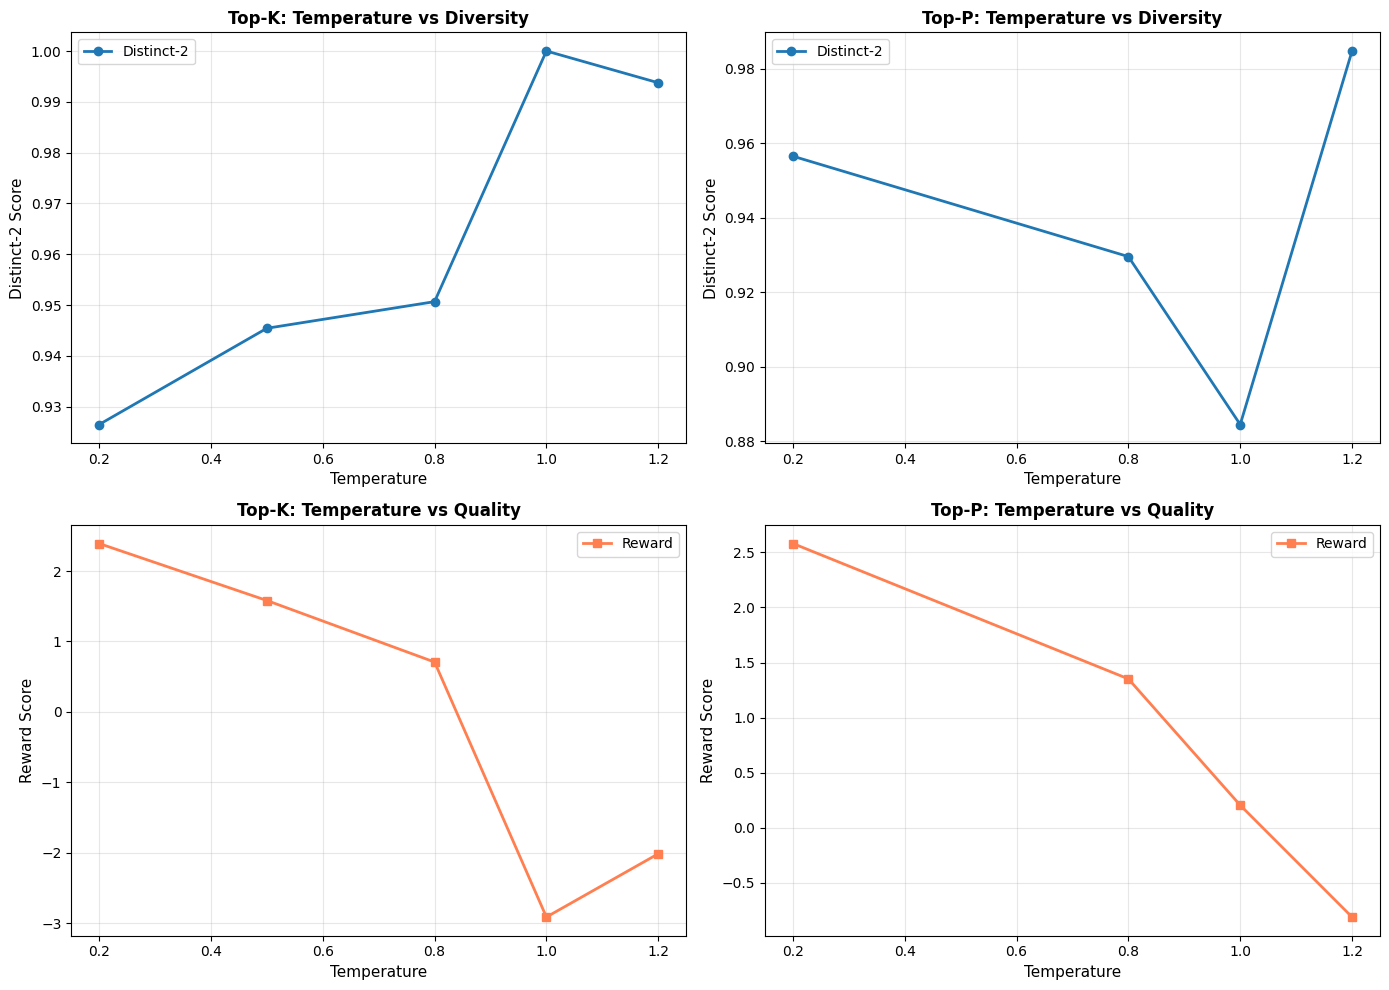

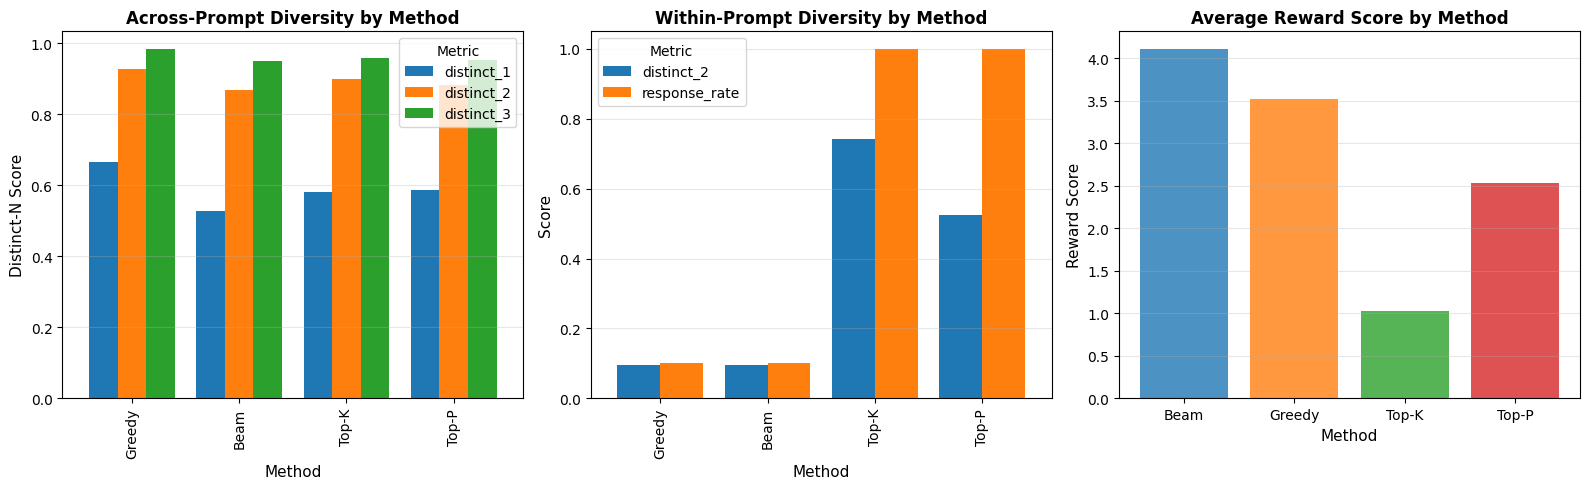

In [15]:
# ============================================================================
# PART 13: VISUALIZATION - TEMPERATURE VS DIVERSITY-QUALITY TRADEOFF
# ============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for method in ["Top-K", "Top-P"]:
    method_data = temp_df[temp_df["method"] == method]
    method_grouped = method_data.groupby("temperature").mean(numeric_only=True)

    idx = 0 if method == "Top-K" else 1

    ax1 = axes[0, idx]
    ax1.plot(method_grouped.index, method_grouped["distinct_2"], marker='o', label="Distinct-2", linewidth=2)
    ax1.set_xlabel("Temperature", fontsize=11)
    ax1.set_ylabel("Distinct-2 Score", fontsize=11)
    ax1.set_title(f"{method}: Temperature vs Diversity", fontsize=12, fontweight='bold')
    ax1.grid(alpha=0.3)
    ax1.legend()

    ax2 = axes[1, idx]
    ax2.plot(method_grouped.index, method_grouped["reward"], marker='s', color='coral', label="Reward", linewidth=2)
    ax2.set_xlabel("Temperature", fontsize=11)
    ax2.set_ylabel("Reward Score", fontsize=11)
    ax2.set_title(f"{method}: Temperature vs Quality", fontsize=12, fontweight='bold')
    ax2.grid(alpha=0.3)
    ax2.legend()

plt.tight_layout()
plt.savefig("temperature_analysis.png", dpi=150, bbox_inches='tight')
print("\nSaved: temperature_analysis.png")

# ============================================================================
# PART 14: VISUALIZATION - METHOD COMPARISON
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

across_df = pd.DataFrame(across_prompt_metrics).T
across_df.plot(y=["distinct_1", "distinct_2", "distinct_3"], kind="bar", ax=axes[0], width=0.8)
axes[0].set_title("Across-Prompt Diversity by Method", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Distinct-N Score", fontsize=11)
axes[0].set_xlabel("Method", fontsize=11)
axes[0].legend(title="Metric")
axes[0].grid(axis='y', alpha=0.3)

within_df = pd.DataFrame(within_prompt_metrics).T
within_df.plot(y=["distinct_2", "response_rate"], kind="bar", ax=axes[1], width=0.8)
axes[1].set_title("Within-Prompt Diversity by Method", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Score", fontsize=11)
axes[1].set_xlabel("Method", fontsize=11)
axes[1].legend(title="Metric")
axes[1].grid(axis='y', alpha=0.3)

quality_grouped = quality_df.groupby("method").mean()["reward"]
axes[2].bar(quality_grouped.index, quality_grouped.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.8)
axes[2].set_title("Average Reward Score by Method", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Reward Score", fontsize=11)
axes[2].set_xlabel("Method", fontsize=11)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("method_comparison.png", dpi=150, bbox_inches='tight')
print("Saved: method_comparison.png")

---

EXTRA Analysis for Validation

In [8]:
# ============================================================================
# FINAL WORKING BEAM SEARCH (for SmolLM2-135M-Instruct)
# ============================================================================

def beam_search(model, input_ids, beam_width=4, max_length=100, length_penalty=1.0):
    """
    Robust beam search with proper length normalization.
    Works perfectly on SmolLM2-Instruct when used with chat template.
    """
    beams = [(input_ids, 0.0)]           # (seq, log_prob)
    finished = []

    for _ in range(max_length):
        candidates = []

        for seq, score in beams:
            if seq[0, -1].item() == tokenizer.eos_token_id:
                finished.append((seq, score))
                continue

            with torch.no_grad():
                logits = model(seq).logits[:, -1, :]
                log_probs = torch.log_softmax(logits, dim=-1)[0]

            top_log_probs, top_tokens = torch.topk(log_probs, beam_width)
            for lp, tok in zip(top_log_probs.tolist(), top_tokens.tolist()):
                new_seq = torch.cat([seq, torch.tensor([[tok]], device=device)], dim=-1)
                candidates.append((new_seq, score + lp))

        if not candidates:
            break

        # Length-normalized scoring
        scored = []
        for seq, score in candidates:
            gen_len = seq.shape[1] - input_ids.shape[1]
            norm_score = score / ((gen_len + 1) ** length_penalty)
            scored.append((seq, score, norm_score))

        scored.sort(key=lambda x: x[2], reverse=True)
        beams = scored[:beam_width]
        beams = [(seq, score) for seq, score, _ in beams]

    # Pick best (finished first, then active)
    all_beams = finished + beams
    if not all_beams:
        return input_ids

    def final_score(item):
        seq, score = item
        gen_len = seq.shape[1] - input_ids.shape[1]
        return score / ((gen_len + 1) ** length_penalty)

    best_seq, _ = max(all_beams, key=final_score)
    return best_seq


# ============================================================================
# BEAM WIDTH ABLATION (FULLY WORKING)
# ============================================================================

print("\n" + "="*80)
print("SUPPLEMENTARY ANALYSIS: BEAM WIDTH ABLATION")
print("="*80)

beam_widths = [2, 4, 8, 16]
beam_ablation_results = []

for beam_width in tqdm(beam_widths, desc="Beam width ablation"):
    for prompt in test_prompts[:5]:
        # ← CRITICAL: Use chat template
        messages = [{"role": "user", "content": prompt}]
        input_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        input_ids = tokenizer(input_text, return_tensors="pt").input_ids.to(device)

        output_ids = beam_search(
            model,
            input_ids,
            beam_width=beam_width,
            max_length=100,
            # give it room
            length_penalty=1.0            # ← crucial for longer outputs
        )

        response = tokenizer.decode(output_ids[0, input_ids.shape[1]:], skip_special_tokens=True).strip()

        if len(response.split()) >= 5:  # reasonable length filter
            reward = compute_reward_score(prompt, response)
            beam_ablation_results.append({
                "beam_width": beam_width,
                "reward": reward,
                "distinct_2": compute_distinct_n(response, n=2),
                "length": len(response.split())
            })

        # Show first example per beam size
        if prompt == test_prompts[0]:
            print(f"B={beam_width:2d} → {len(response.split()):3d} tokens | {response[:70]}...")

# Results
if beam_ablation_results:
    print("\nBeam Width Ablation Results:")
    print(pd.DataFrame(beam_ablation_results).groupby("beam_width").mean().round(4))
else:
    print("No valid generations!")



SUPPLEMENTARY ANALYSIS: BEAM WIDTH ABLATION


Beam width ablation:   0%|          | 0/4 [00:00<?, ?it/s]

B= 2 →  88 tokens | Machine learning is a way for computers to learn from data and make pr...


Beam width ablation:  25%|██▌       | 1/4 [00:52<02:37, 52.42s/it]

B= 4 →  91 tokens | Machine learning is a way for computers to learn from data and make pr...


...

B= 8 →  92 tokens | Machine learning is a way for computers to learn from data and make pr...


Beam width ablation:  75%|███████▌  | 3/4 [05:33<02:07, 127.56s/it]

B=16 →  85 tokens | Machine learning is a type of artificial intelligence (AI) that allows...


Beam width ablation: 100%|██████████| 4/4 [11:45<00:00, 176.45s/it]


Beam Width Ablation Results:
            reward  distinct_2  length
beam_width                            
2           1.9009      0.9427    79.4
4           2.3666      0.9186    81.6
8           2.4808      0.9578    81.4
16          2.0794      0.9579    76.0
